In [1]:
import torch
import torch.nn.utils.prune as prune
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn.utils.prune as prune
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from models import ResNet18
from torchinfo import summary

In [2]:
# Load ResNet model
model = ResNet18()
checkpoint = torch.load('Models Weights/Resnet18_V2.pth', map_location='cuda')
state_dict = checkpoint['net']

/tmp/ipykernel_1704244/1163781334.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('Models Weights/Resnet18_V2.pth', map_location='cuda')


In [3]:
# Remove 'module.' if using DataParallel
new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [4]:
# Move model to GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

In [5]:
# Lists to track metrics
train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_epoch = 0
best_state = None

In [6]:
# Data
print('==> Preparing data..')
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=100, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified


In [7]:
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0

    use_amp = (device == "cuda")
    with torch.inference_mode():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    outputs = model(inputs)
            else:
                outputs = model(inputs)  # keep float32 on CPU

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100 * correct / total
    print(f"Accuracy: {acc:.2f}%")
    return acc

In [8]:
# Evaluate the quantized model
evaluate(model, testloader)

Accuracy: 95.44%


95.44

In [9]:
#summary(model, input_size=(128, 3, 32, 32), dtypes=[torch.float16], device=device)

In [10]:
# list of pruning amounts
pruning_amounts = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Structured pruning settings
pruning_n = 2
pruning_dim = 0  # dim=0 prunes output channels (filters) in Conv2d

Accuracy: 95.44%
Accuracy: 94.74%
Accuracy: 89.79%
Accuracy: 65.97%
Accuracy: 27.99%
Accuracy: 16.81%
Accuracy: 10.62%
Accuracy: 10.00%
Accuracy: 10.08%


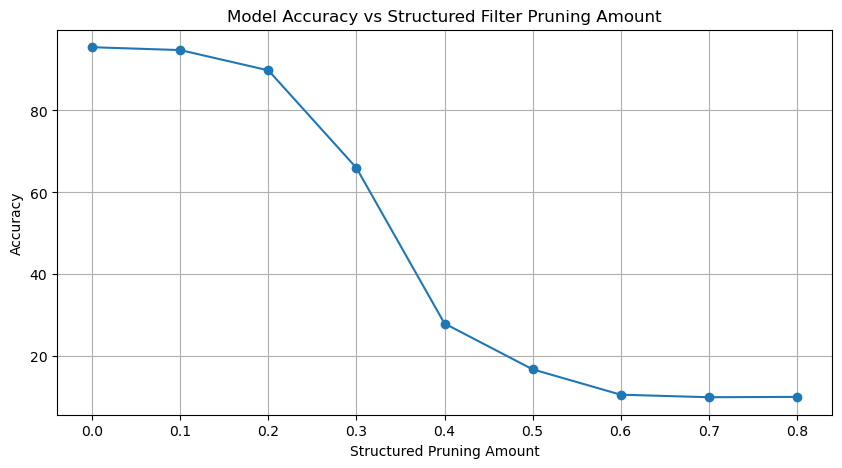

In [11]:
# Structured pruning from the same original model for each amount (non-cumulative)
import copy

accuracies = []

# Build a clean base model once from original checkpoint weights
base_model = ResNet18().to(device)
base_model.load_state_dict(new_state_dict)
base_model.half()

for amount in pruning_amounts:
    # Fresh copy every iteration so pruning does NOT accumulate
    model_pruned = copy.deepcopy(base_model)

    # Apply structured pruning layer-by-layer on Conv2d filters
    for module in model_pruned.modules():
        if isinstance(module, nn.Conv2d):
            prune.ln_structured(
                module,
                name='weight',
                amount=amount,
                n=pruning_n,
                dim=pruning_dim,
            )
            prune.remove(module, 'weight')

    acc = evaluate(model_pruned, testloader)
    accuracies.append(acc)

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(pruning_amounts, accuracies, marker='o')
plt.xlabel('Structured Pruning Amount')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs Structured Filter Pruning Amount')
plt.grid(True)
plt.show()


===== Structured pruning amount: 0.1 =====
Accuracy: 94.74%
Pre-finetune accuracy (0.1): 94.74%
==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified
==> Building model..

Epoch: 0
 [================================================================>]  Step: 2s379ms | Tot: 1m5s | Loss: 1.606 | Acc: 48.338% (24169/5000 391/391   
 [================================================================>]  Step: 55ms | Tot: 5s524ms | Loss: 1.085 | Acc: 64.940% (6494/1000 100/100 
Saving..

Epoch: 1
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.395 | Acc: 57.391% (28695/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s525ms | Loss: 1.114 | Acc: 63.800% (6380/1000 100/100 

Epoch: 2
 [================================================================>]  Step: 106ms | Tot: 1m2s | Loss: 1.361 | Acc: 58.452% (29226/5000 391/391 91  
 [==========

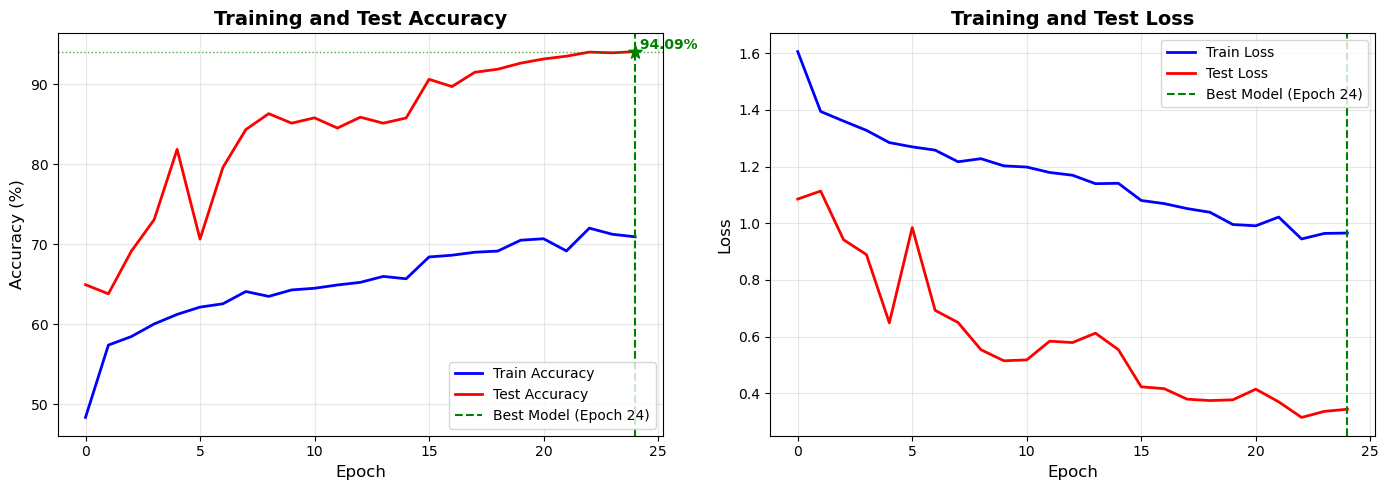

Best model achieved 94.09% accuracy at epoch 24
Best model saved at ./Models Weights/Resnet18_structured_pruned_10_augmix_25ep.pth


===== Structured pruning amount: 0.3 =====
Accuracy: 65.97%
Pre-finetune accuracy (0.3): 65.97%
==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified
==> Building model..

Epoch: 0
 [================================================================>]  Step: 106ms | Tot: 1m2s | Loss: 1.899 | Acc: 32.456% (16228/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s520ms | Loss: 1.510 | Acc: 45.390% (4539/1000 100/100 
Saving..

Epoch: 1
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.587 | Acc: 47.994% (23996/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s522ms | Loss: 1.173 | Acc: 61.230% (6123/1000 100/100 
Saving..

Epoch: 2
 [=================

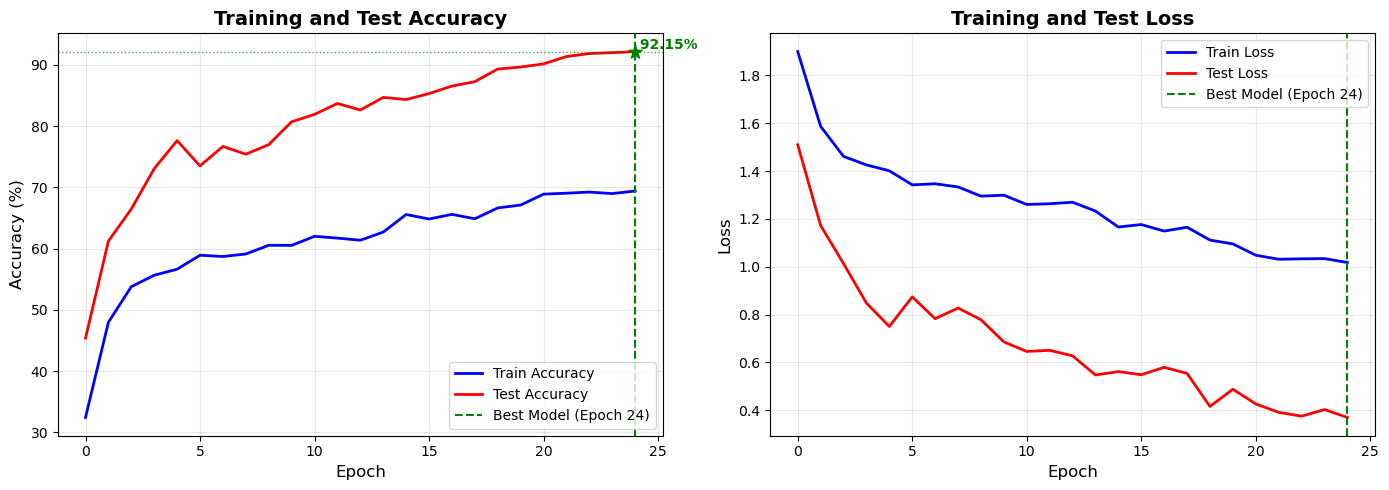

Best model achieved 92.15% accuracy at epoch 24
Best model saved at ./Models Weights/Resnet18_structured_pruned_30_augmix_25ep.pth


===== Structured pruning amount: 0.5 =====
Accuracy: 16.81%
Pre-finetune accuracy (0.5): 16.81%
==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified
==> Building model..

Epoch: 0
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.848 | Acc: 35.340% (17670/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s519ms | Loss: 1.518 | Acc: 47.450% (4745/1000 100/100 
Saving..

Epoch: 1
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.578 | Acc: 48.685% (24342/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s518ms | Loss: 1.128 | Acc: 62.280% (6228/1000 100/100 
Saving..

Epoch: 2
 [=================

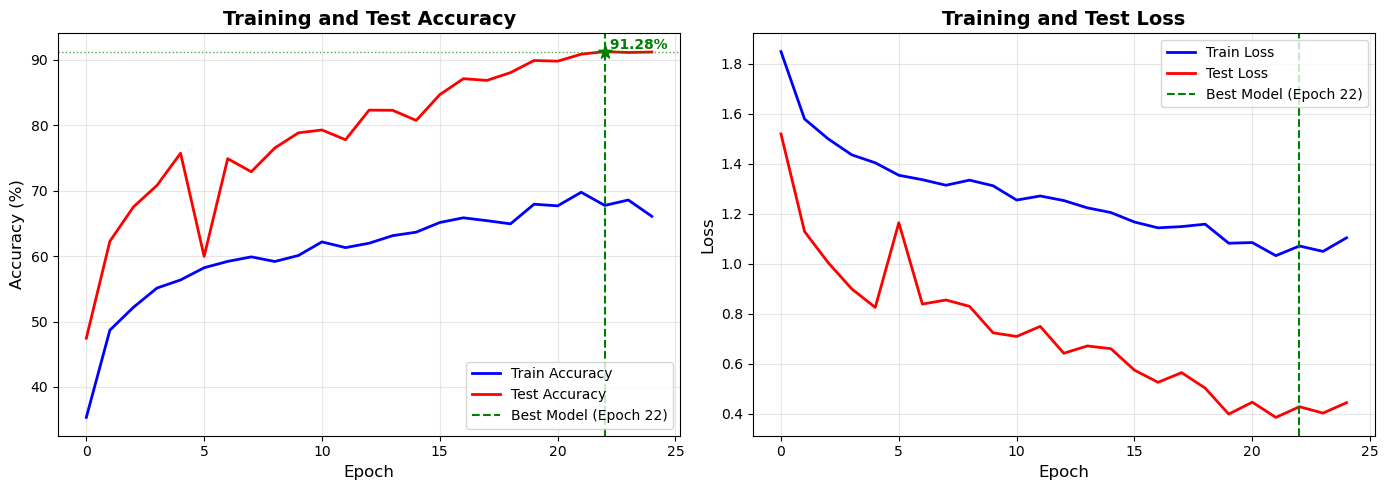

Best model achieved 91.28% accuracy at epoch 22
Best model saved at ./Models Weights/Resnet18_structured_pruned_50_augmix_25ep.pth


===== Structured pruning amount: 0.7 =====
Accuracy: 10.00%
Pre-finetune accuracy (0.7): 10.00%
==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified
==> Building model..

Epoch: 0
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 2.011 | Acc: 26.684% (13341/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s520ms | Loss: 1.619 | Acc: 42.550% (4255/1000 100/100 
Saving..

Epoch: 1
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.708 | Acc: 42.300% (21149/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s523ms | Loss: 1.294 | Acc: 54.830% (5483/1000 100/100 
Saving..

Epoch: 2
 [=================

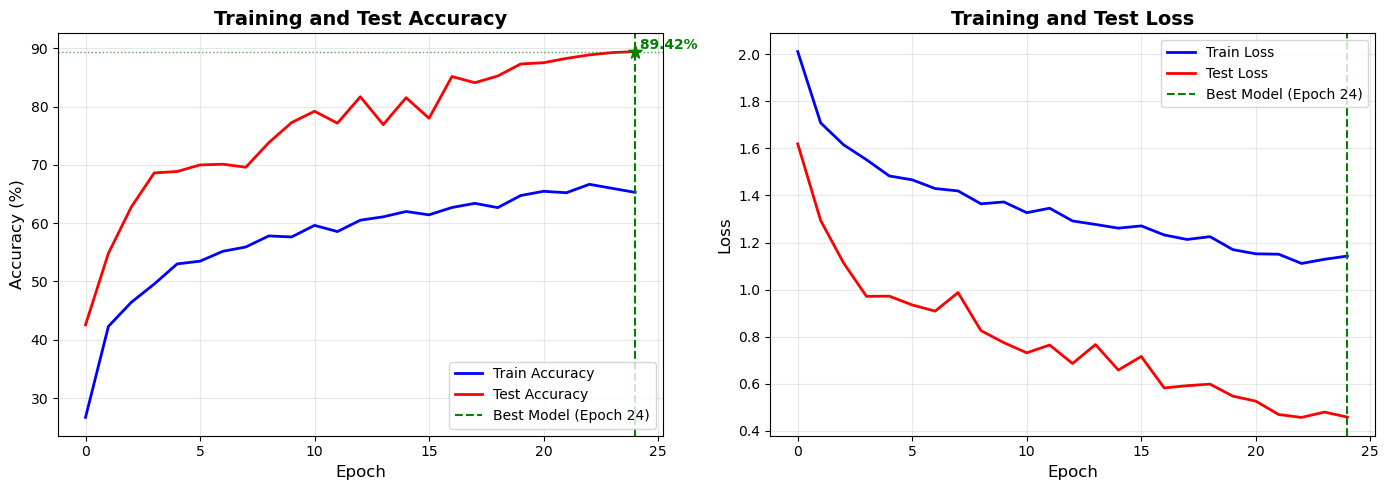

Best model achieved 89.42% accuracy at epoch 24
Best model saved at ./Models Weights/Resnet18_structured_pruned_70_augmix_25ep.pth



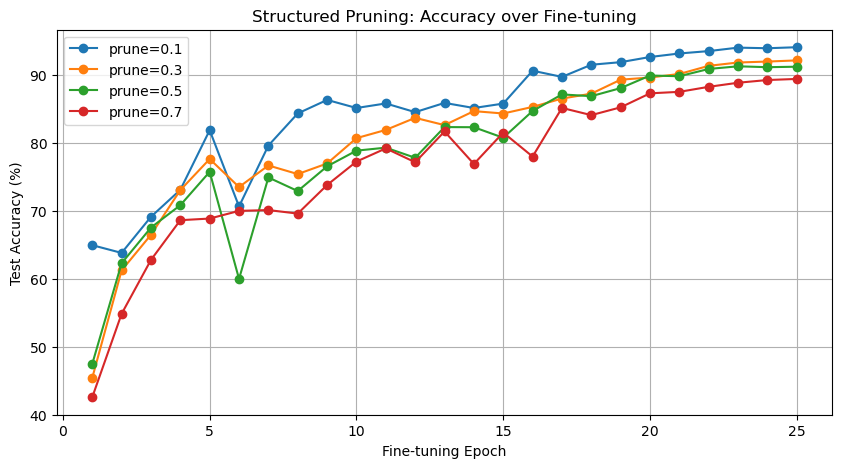

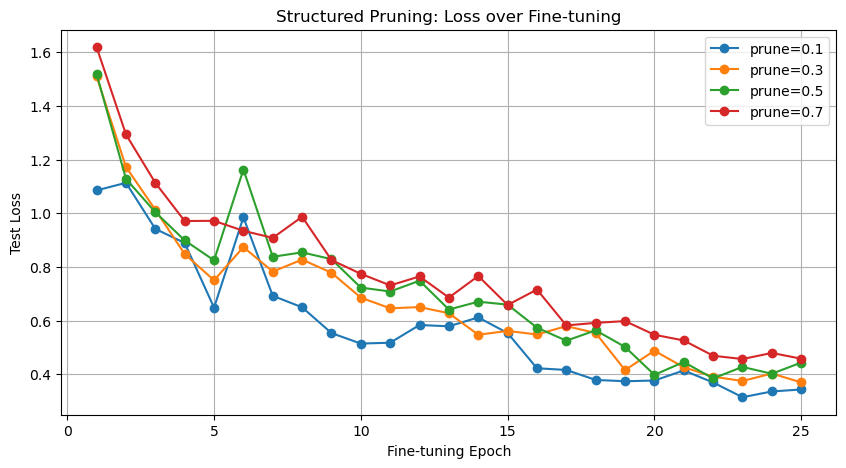

prune=0.1 | best_acc=94.09% at epoch 24 | saved=./Models Weights/Resnet18_structured_pruned_10_augmix_25ep.pth
prune=0.3 | best_acc=92.15% at epoch 24 | saved=./Models Weights/Resnet18_structured_pruned_30_augmix_25ep.pth
prune=0.5 | best_acc=91.28% at epoch 22 | saved=./Models Weights/Resnet18_structured_pruned_50_augmix_25ep.pth
prune=0.7 | best_acc=89.42% at epoch 24 | saved=./Models Weights/Resnet18_structured_pruned_70_augmix_25ep.pth


In [12]:
import copy
import importlib
import train_augmentation
import matplotlib.pyplot as plt

# Reload to pick latest changes
importlib.reload(train_augmentation)

# 4 structured pruning levels to compare during fine-tuning
pruning_amounts_finetune = [0.1, 0.3, 0.5, 0.7]
epochs_finetune = 25

histories = {}

for prune_amount in pruning_amounts_finetune:
    print(f"\n===== Structured pruning amount: {prune_amount} =====")
    model_to_train = copy.deepcopy(base_model)

    for module in model_to_train.modules():
        if isinstance(module, nn.Conv2d):
            prune.ln_structured(
                module,
                name='weight',
                amount=prune_amount,
                n=pruning_n,
                dim=pruning_dim,
            )
            prune.remove(module, 'weight')

    pre_ft_acc = evaluate(model_to_train, testloader)
    print(f"Pre-finetune accuracy ({prune_amount}): {pre_ft_acc:.2f}%")

    results = train_augmentation.train_with_augmentation(
        model=model_to_train,
        epochs=epochs_finetune,
        resume=False,
        mixup=True,
        mixup_alpha=1.0,
        save_name=f"Resnet18_structured_pruned_{int(prune_amount*100)}_augmix_{epochs_finetune}ep",
        lr=0.1,
    )

    histories[prune_amount] = {
        'test_accs': results['test_accs'],
        'test_losses': results['test_losses'],
        'best_acc': results['best_acc'],
        'best_epoch': results['best_epoch'],
        'save_path': results['save_path'],
    }

# Plot 1: accuracy over fine-tuning epochs for the 4 pruned models
epochs = range(1, epochs_finetune + 1)
plt.figure(figsize=(10, 5))
for amount in pruning_amounts_finetune:
    plt.plot(epochs, histories[amount]['test_accs'], marker='o', label=f'prune={amount}')
plt.xlabel('Fine-tuning Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Structured Pruning: Accuracy over Fine-tuning')
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: loss over fine-tuning epochs for the 4 pruned models
plt.figure(figsize=(10, 5))
for amount in pruning_amounts_finetune:
    plt.plot(epochs, histories[amount]['test_losses'], marker='o', label=f'prune={amount}')
plt.xlabel('Fine-tuning Epoch')
plt.ylabel('Test Loss')
plt.title('Structured Pruning: Loss over Fine-tuning')
plt.grid(True)
plt.legend()
plt.show()

for amount in pruning_amounts_finetune:
    h = histories[amount]
    print(
        f"prune={amount} | best_acc={h['best_acc']:.2f}% at epoch {h['best_epoch']} | saved={h['save_path']}"
    )